In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import cv2
import numpy as np
from fastapi import FastAPI, UploadFile, File, Form, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
from typing import Optional
import matplotlib.pyplot as plt
from src.detector import FaceDetector
from src.aligner import FaceAligner
from src.recognizer import FaceRecognizer
from src.matcher import FaceMatcher
import matplotlib.patches as patches
import importlib
import os

In [3]:
matcher = FaceMatcher(index_file="./databases/db.bin", map_file="./databases/db.json")
detector = FaceDetector(model_path="./models/detector.onnx")
aligner = FaceAligner()
recognizer = FaceRecognizer(model_path="./models/recognizer.onnx")

C:\Users\Ankkun\AppData\Roaming\Python\Python314\site-packages\onnxruntime\capi\onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


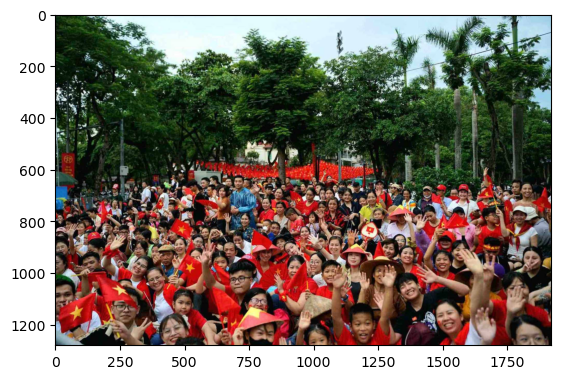

In [4]:
img1 = cv2.imread("test1.jpg")
img2 = cv2.imread("test2.jpg")
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
imgoneface = cv2.imread("a.jpg")
imgoneface = cv2.cvtColor(imgoneface, cv2.COLOR_BGR2RGB)
plt.imshow(img1, cmap="gray")
plt.show()

In [5]:
bboxes, landmarks = detector.detect(img1, 0.5, input_size=(640, 640))
bboxes2, landmarks2 = detector.detect(img2, 0.5, input_size=(640, 640))
bboxes3, landmarks3 = detector.detect(imgoneface, 0.5, input_size=(640, 640))

In [6]:

def draw_scrfd_predictions(image_path: str, bboxes: np.ndarray, landmarks: np.ndarray, show: bool = True):
    """
    Dùng Matplotlib để vẽ Bbox và Landmarks chuẩn chỉnh.
    """
    # 1. Đọc ảnh bằng OpenCV
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print("Không tìm thấy ảnh!")
        return

    # --- BƯỚC QUAN TRỌNG: Chuyển BGR sang RGB ---
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # 2. Khởi tạo khung vẽ Matplotlib
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(img_rgb)

    # 3. Duyệt qua từng khuôn mặt
    for i in range(len(bboxes)):
        # Trích xuất Bbox [x1, y1, x2, y2, score]
        x1, y1, x2, y2, score = bboxes[i]
        w, h = x2 - x1, y2 - y1

        # --- VẼ BOUNDING BOX (Dùng Patches) ---
        rect = patches.Rectangle(
            (x1, y1), w, h, 
            linewidth=2, edgecolor='#FF00FF', facecolor='none'
        )
        ax.add_patch(rect)

        # Vẽ nhãn Score
        ax.text(
            x1, y1 - 10, f'Face: {score:.2f}',
            bbox=dict(facecolor='#FF00FF', alpha=0.8, edgecolor='none'),
            color='white', fontsize=9, fontweight='bold'
        )

        # --- VẼ LANDMARKS (Dùng Scatter) ---
        # landmarks[i] có dạng [[x,y], [x,y], [x,y], [x,y], [x,y]]
        lms = np.array(landmarks[i])
        ax.scatter(lms[:, 0], lms[:, 1], s=20, c='#00FFFF', marker='o', edgecolors='black', linewidths=0.5)

        # --- VẼ ĐƯỜNG NỐI (Vẽ đường xanh lá) ---
        # Nối mắt trái (0) sang mắt phải (1)
        ax.plot([lms[0,0], lms[1,0]], [lms[0,1], lms[1,1]], color='#00FF00', linewidth=1, alpha=0.6)
        # Nối khóe miệng trái (3) sang khóe miệng phải (4)
        ax.plot([lms[3,0], lms[4,0]], [lms[3,1], lms[4,1]], color='#00FF00', linewidth=1, alpha=0.6)

    # Tắt trục tọa độ cho đẹp
    plt.axis('off')
    plt.title("SCRFD Detection Result (Matplotlib Visualization)")
    plt.tight_layout()
    plt.show()

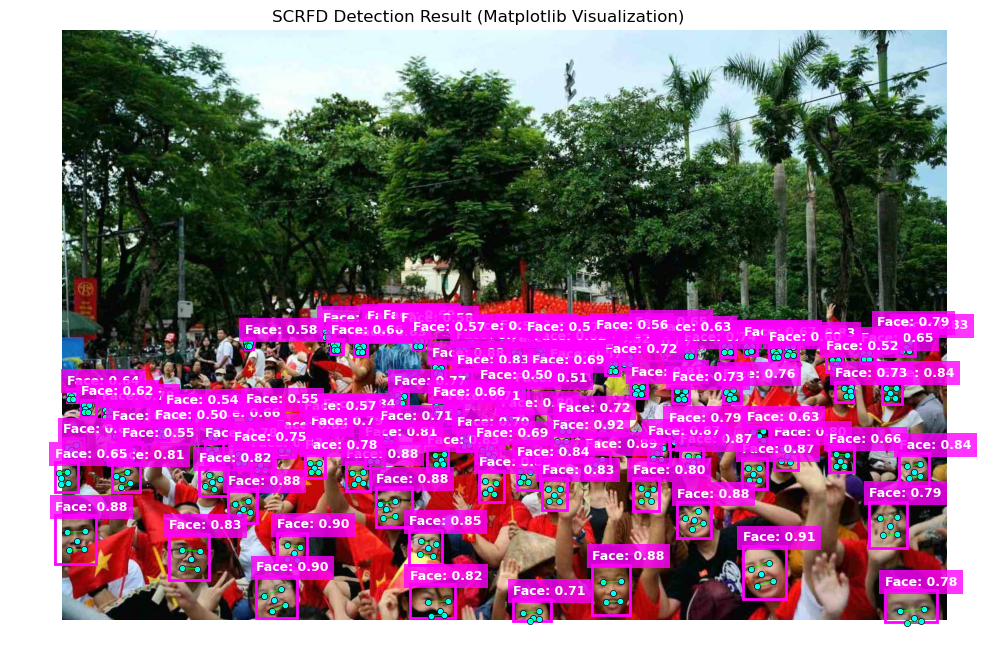

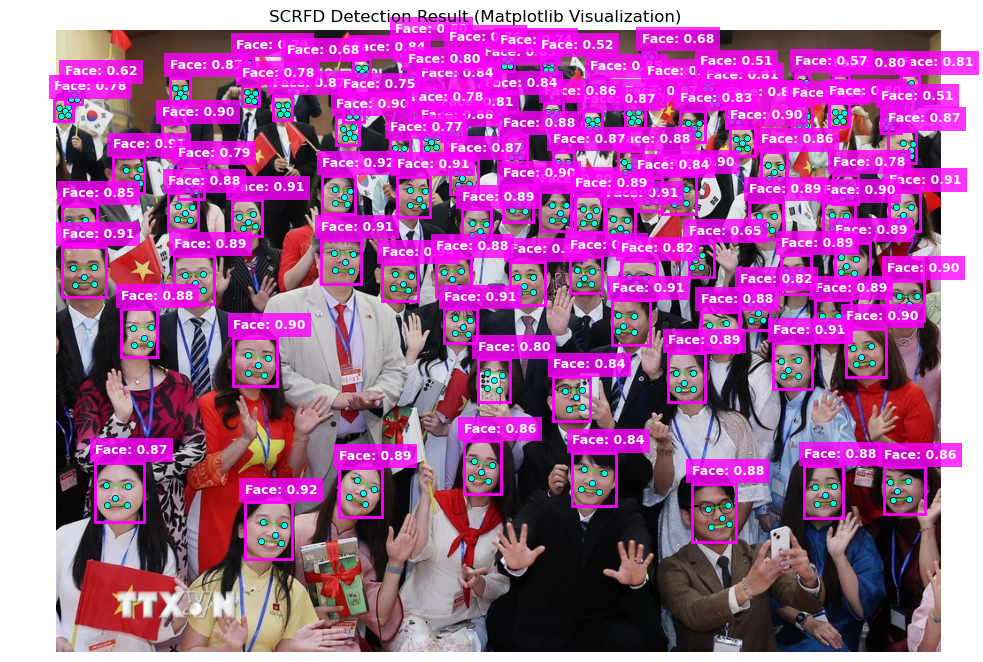

In [7]:
draw_scrfd_predictions("test1.jpg", bboxes, landmarks)
draw_scrfd_predictions("test2.jpg", bboxes2, landmarks2)

In [8]:
landmarks3.shape

(1, 5, 2)

In [9]:
landmarks[1].shape

(5, 2)

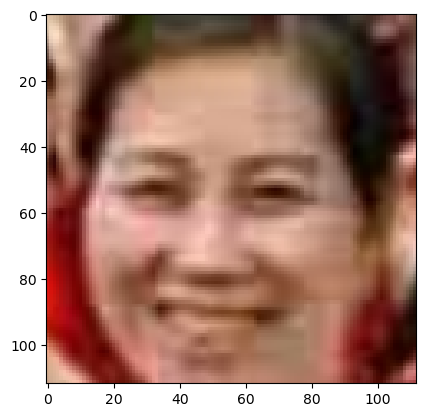

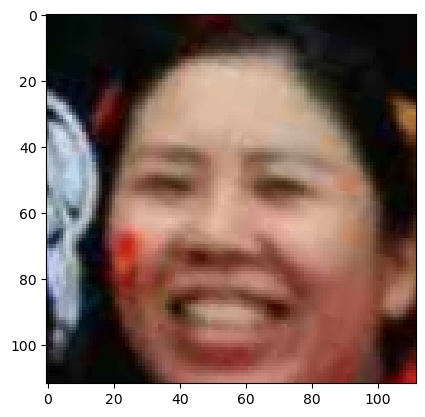

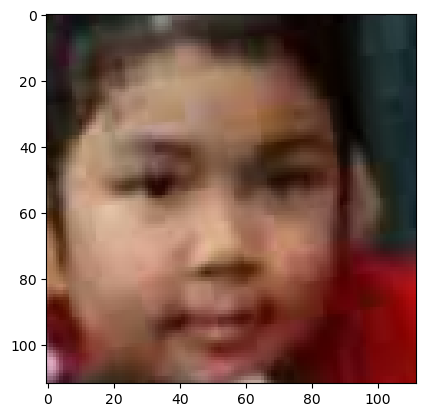

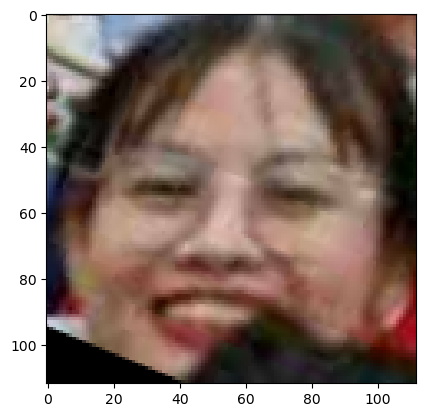

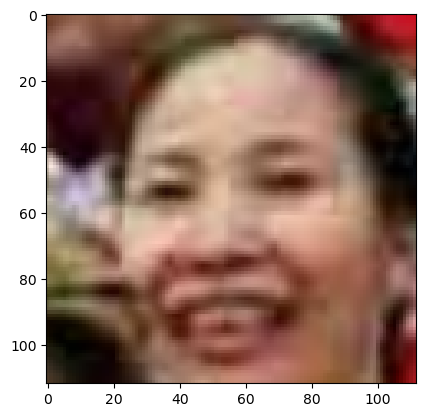

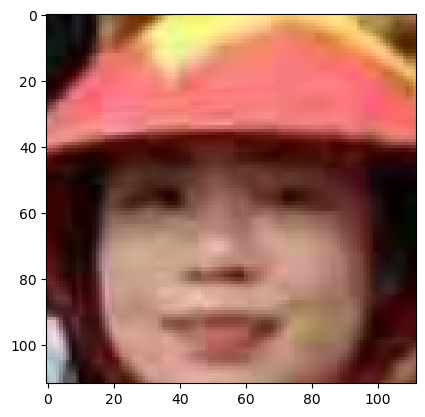

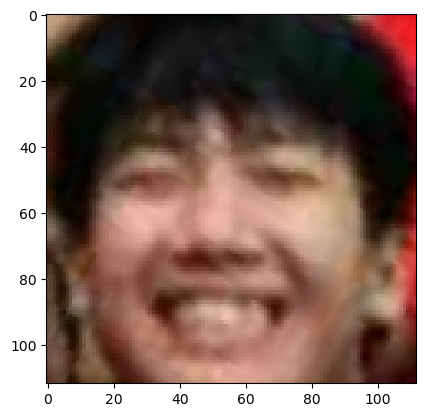

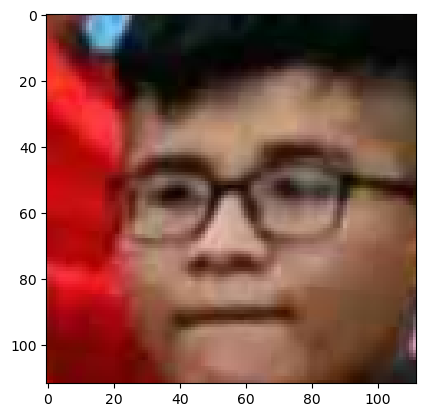

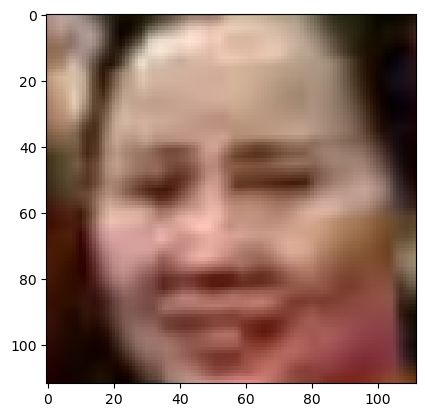

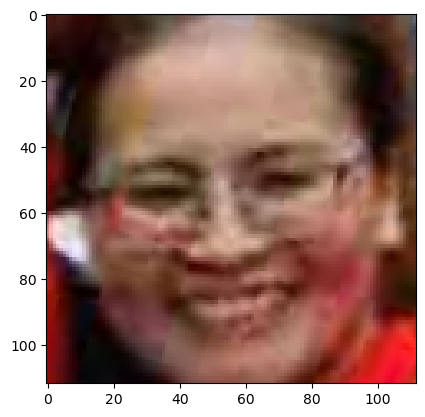

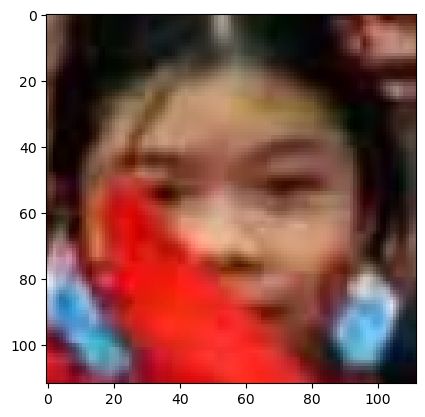

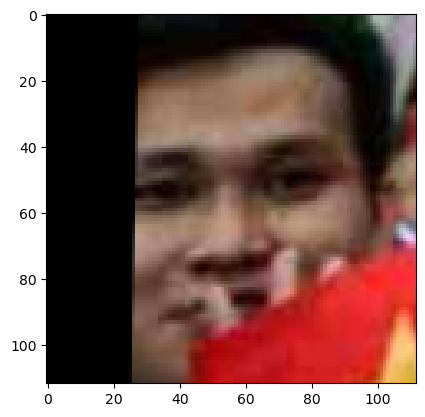

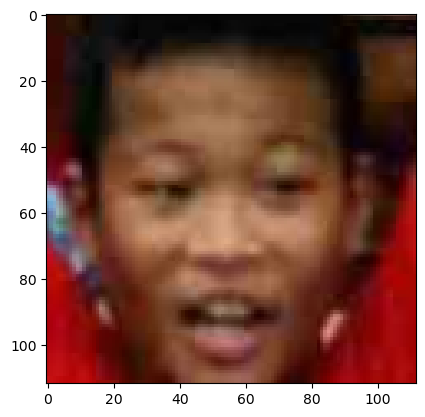

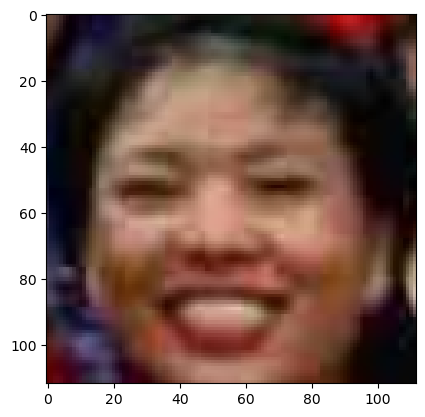

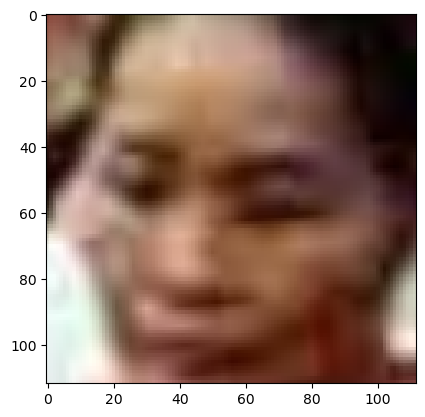

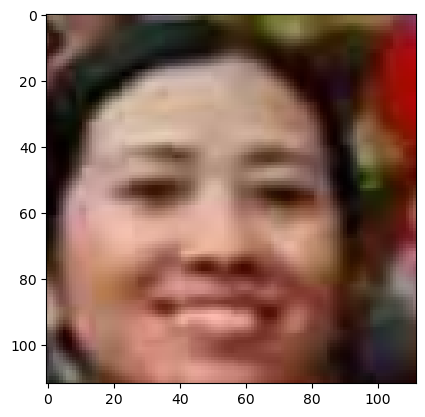

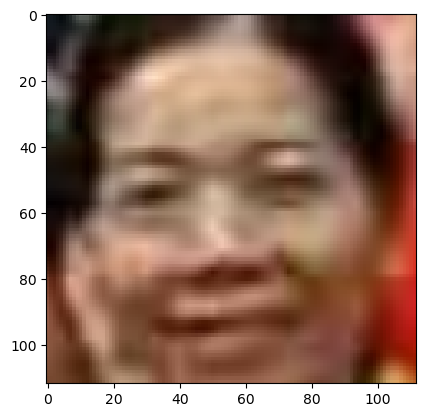

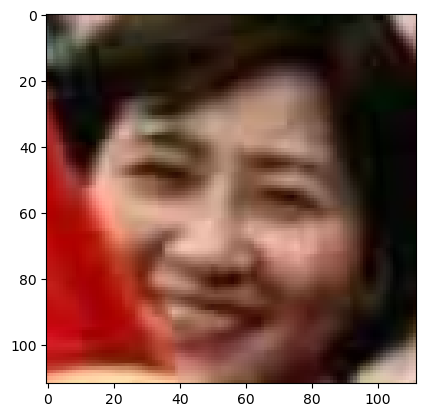

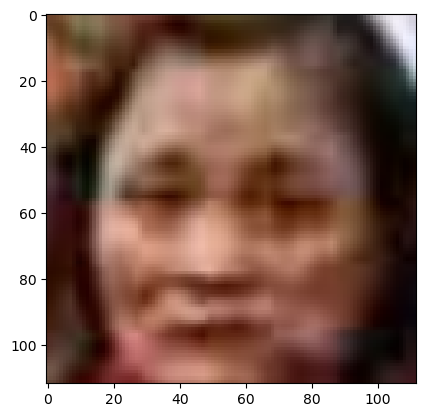

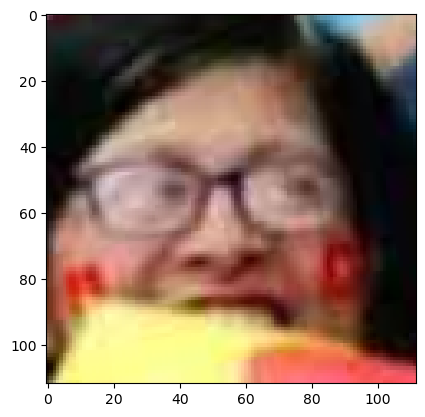

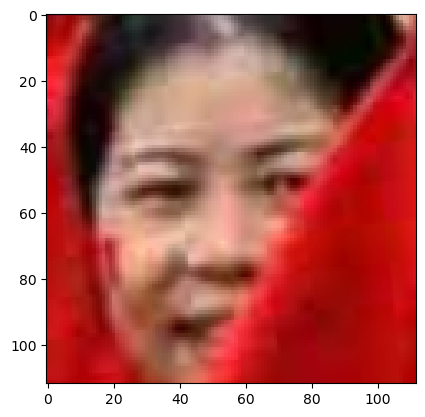

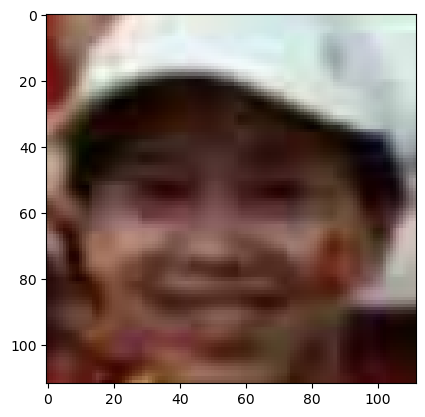

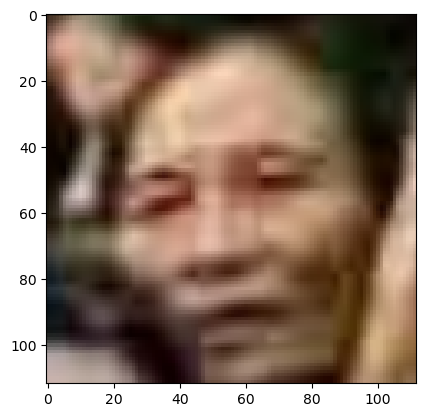

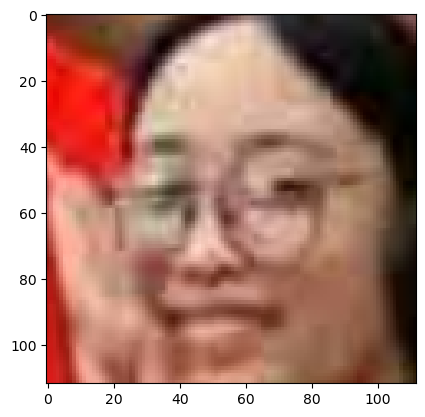

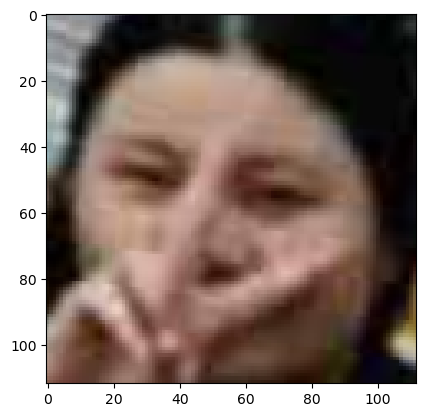

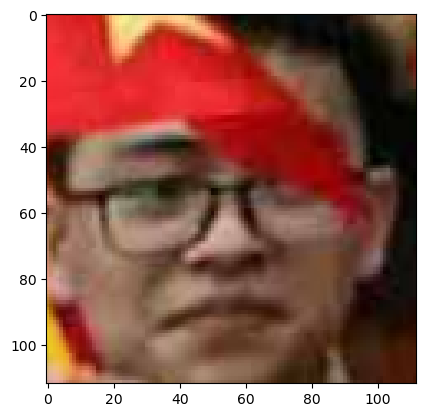

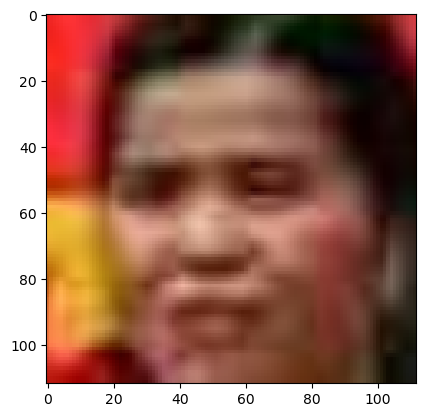

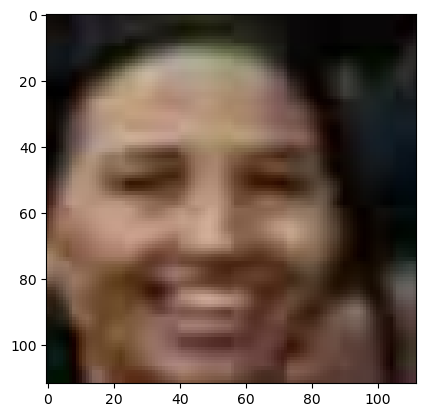

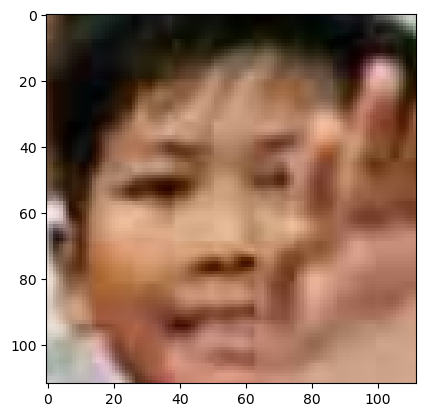

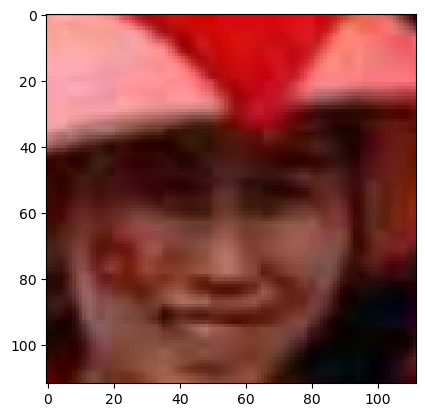

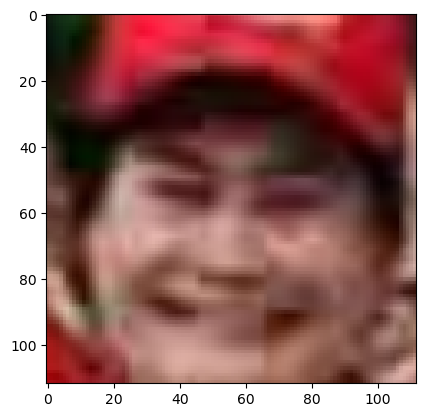

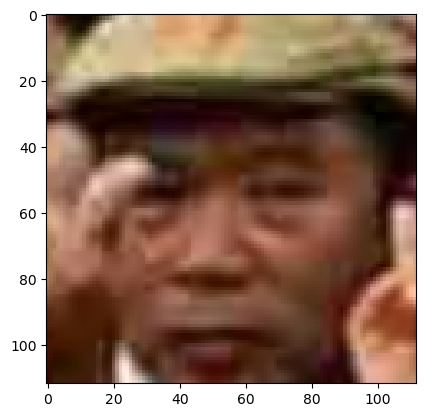

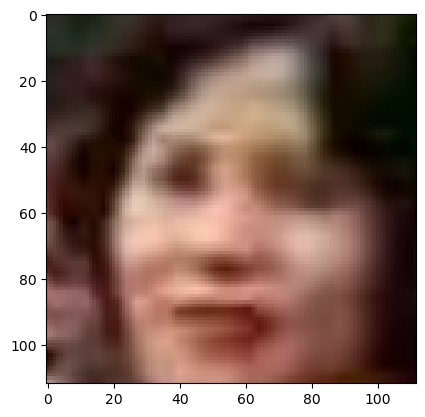

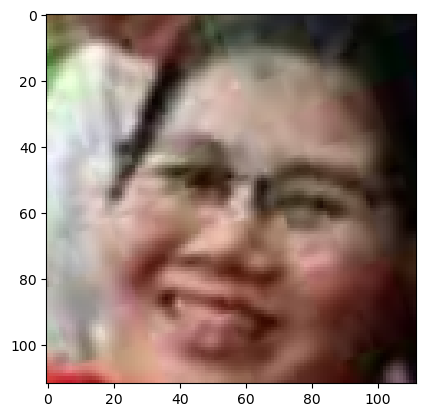

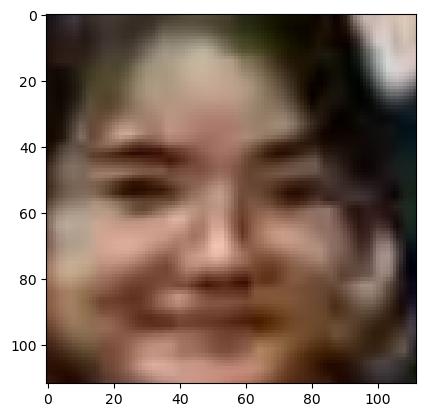

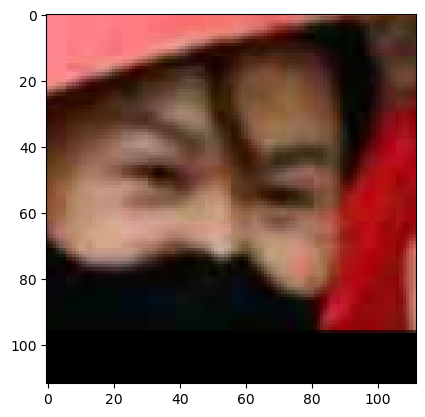

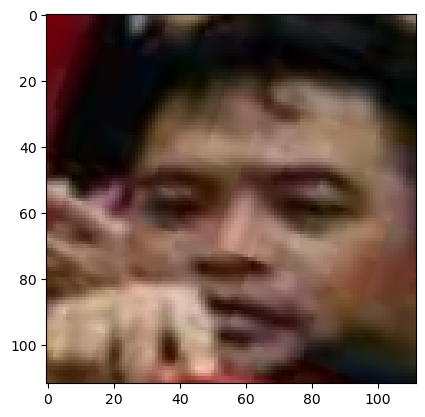

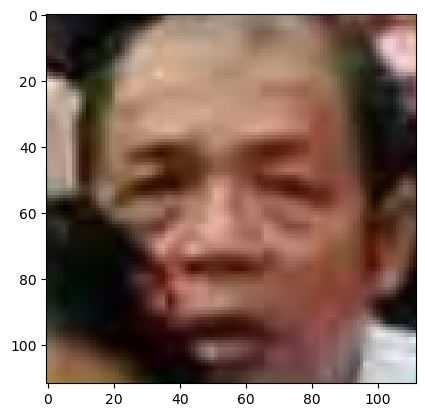

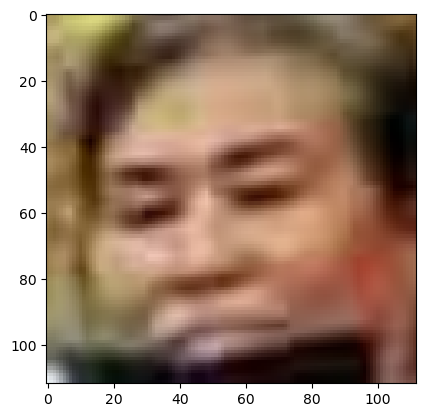

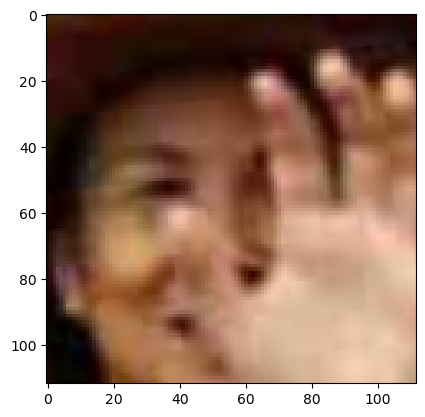

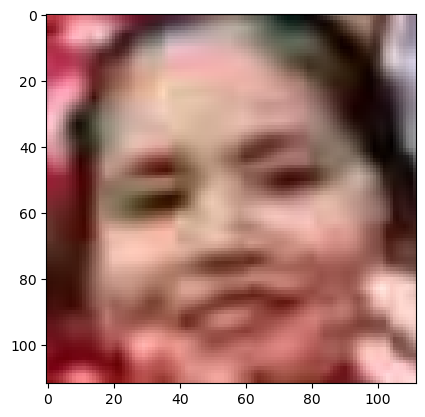

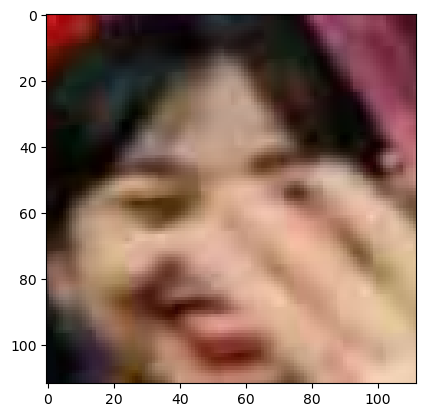

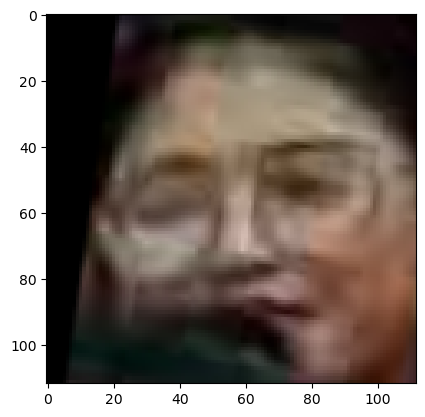

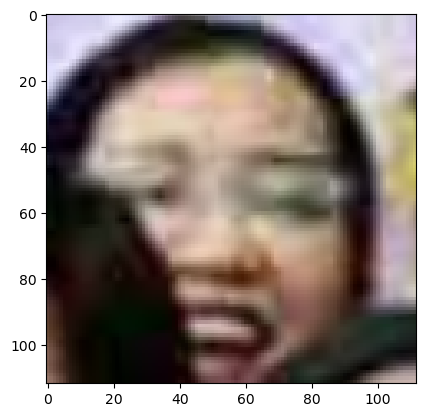

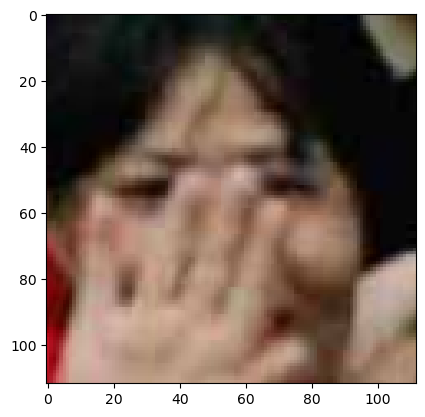

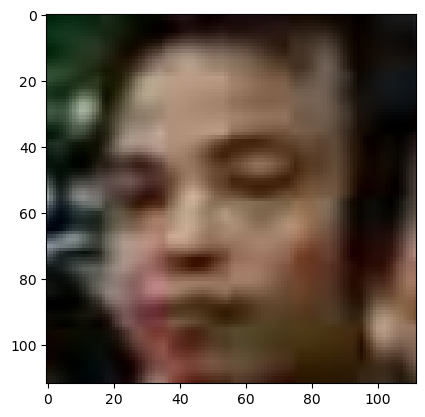

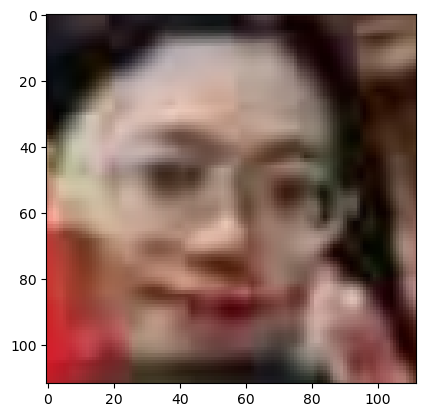

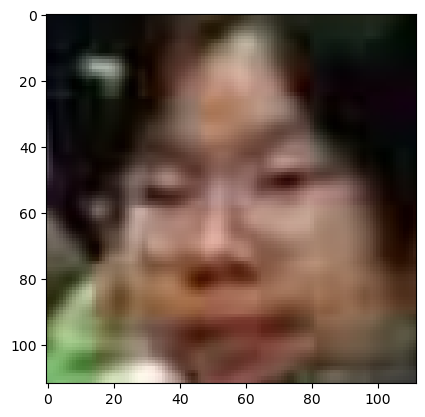

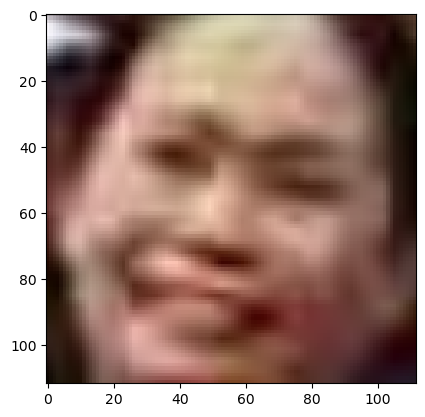

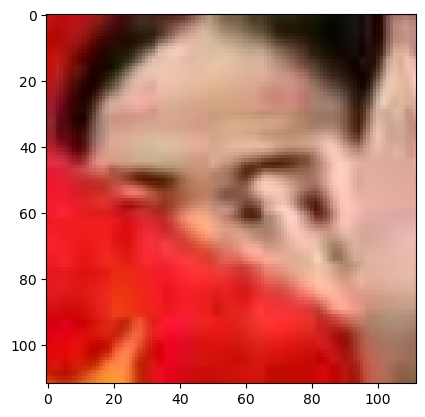

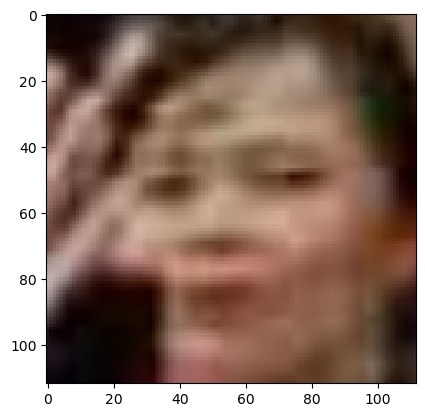

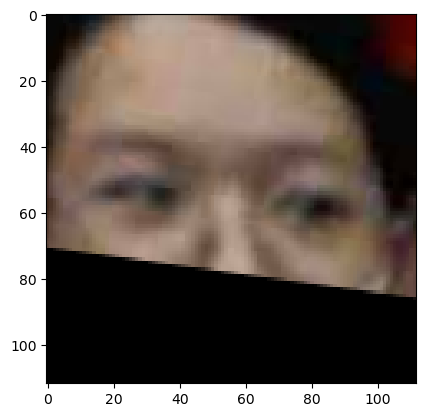

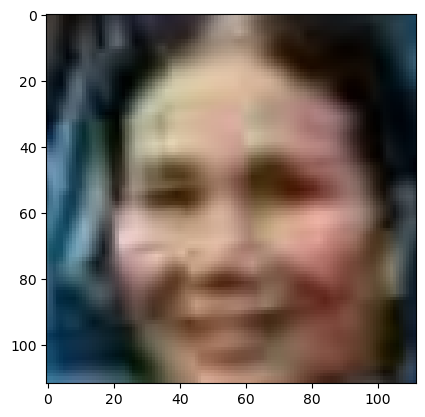

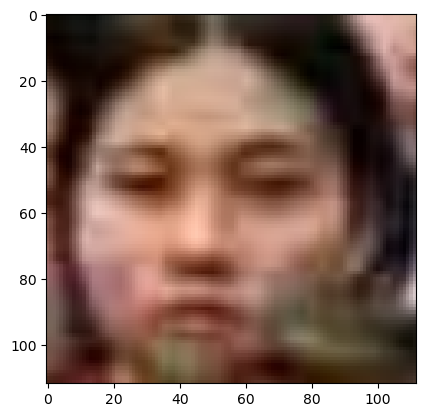

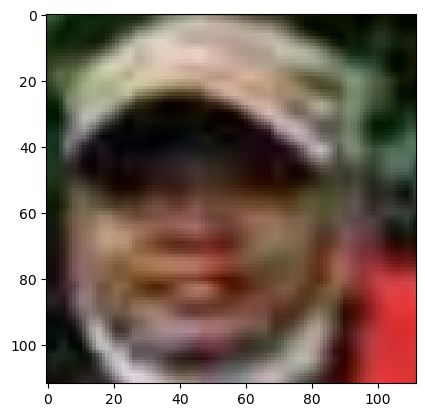

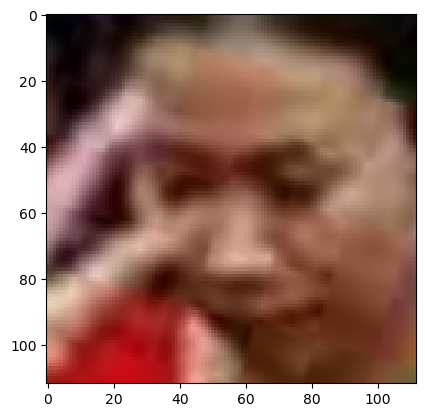

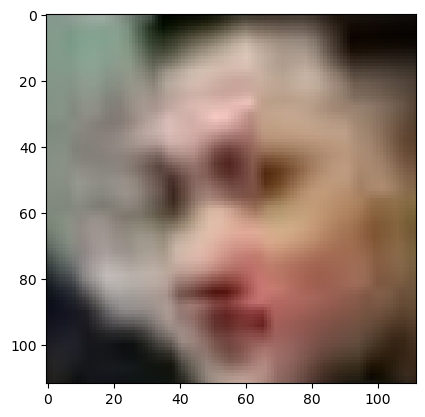

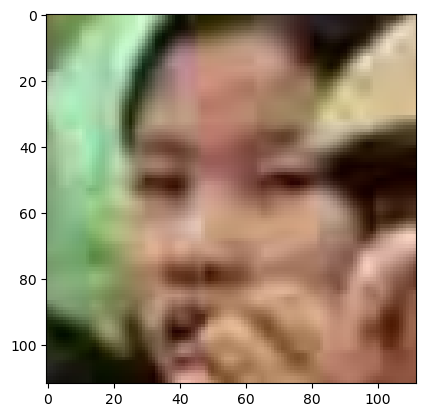

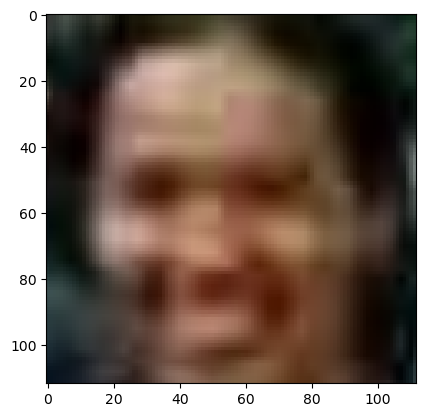

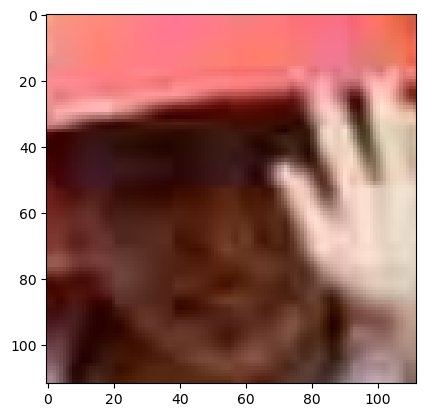

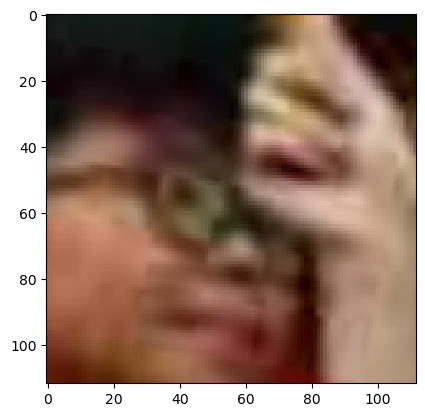

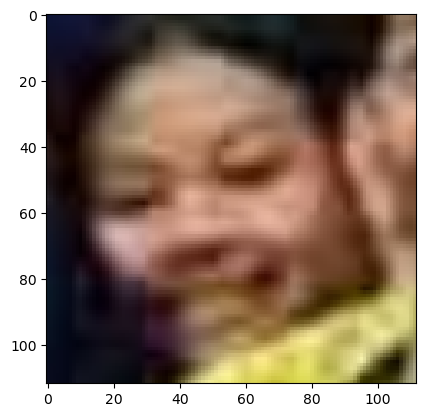

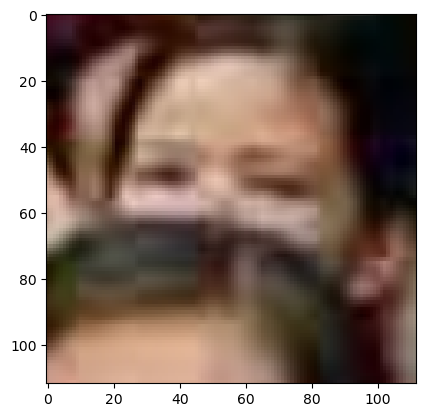

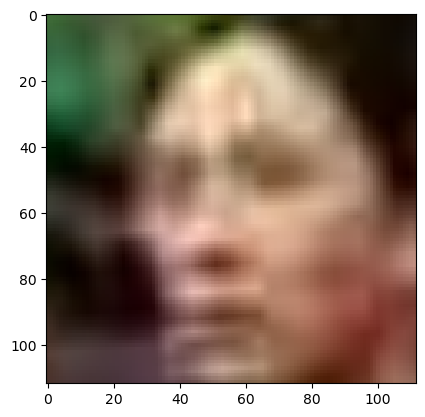

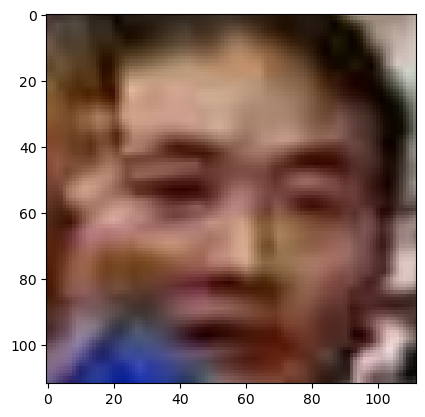

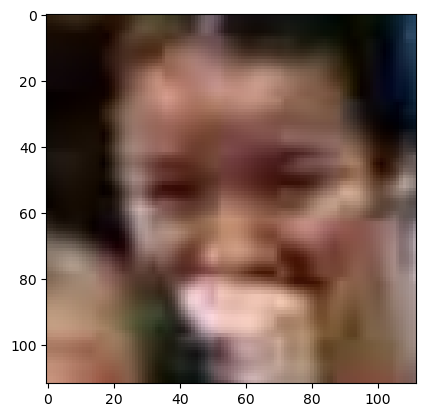

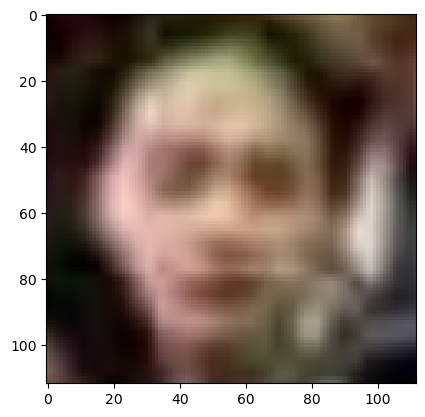

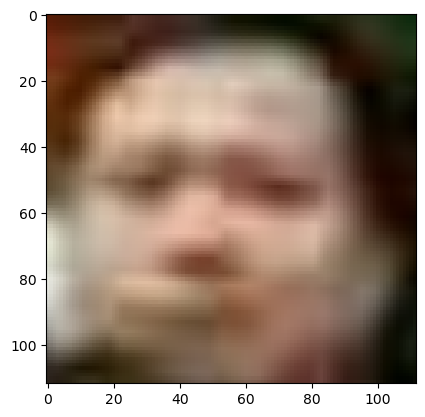

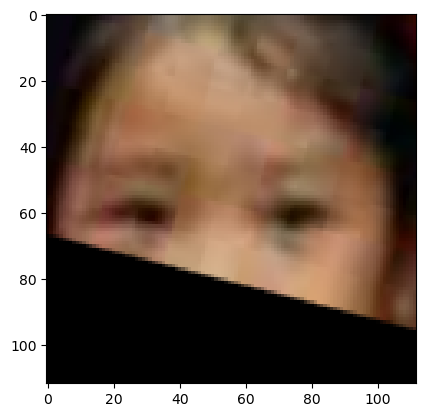

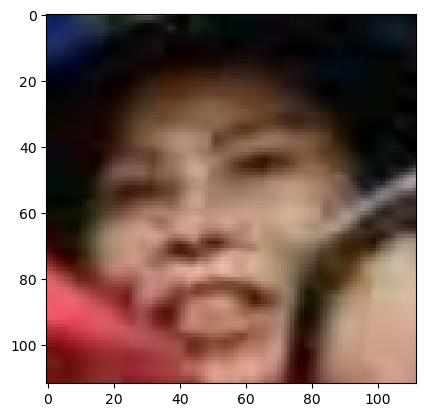

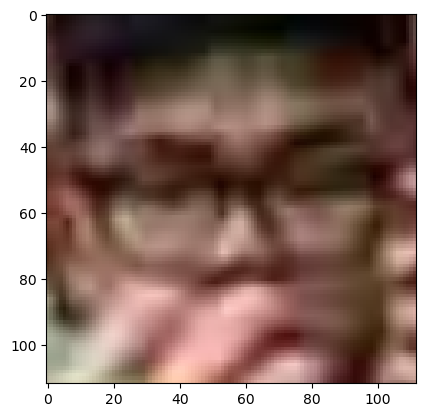

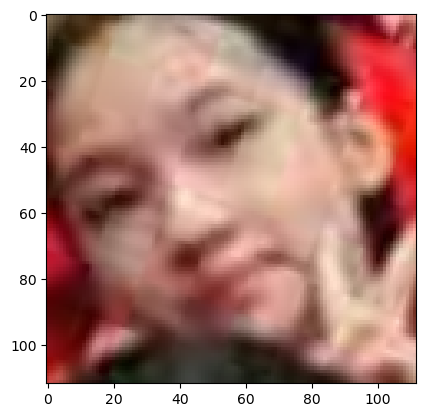

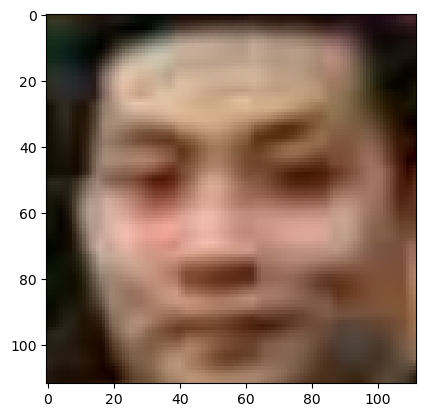

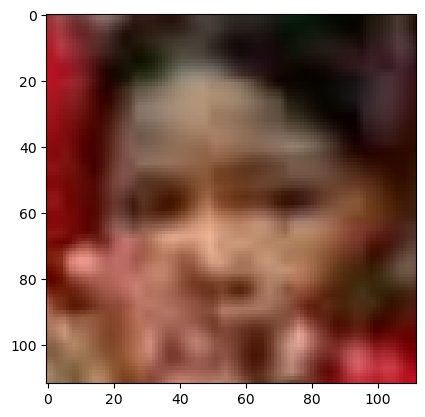

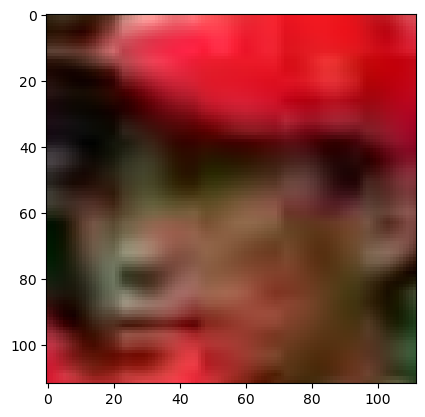

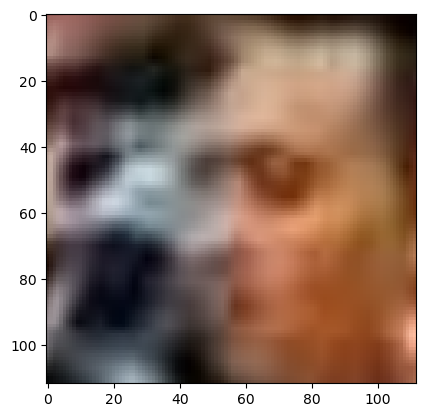

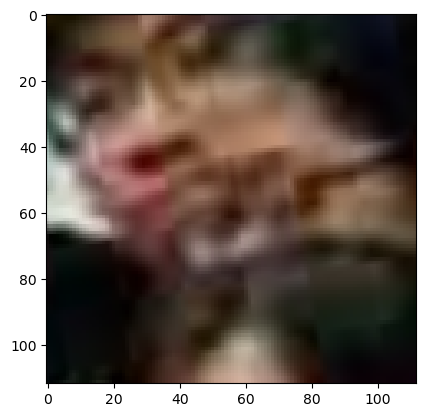

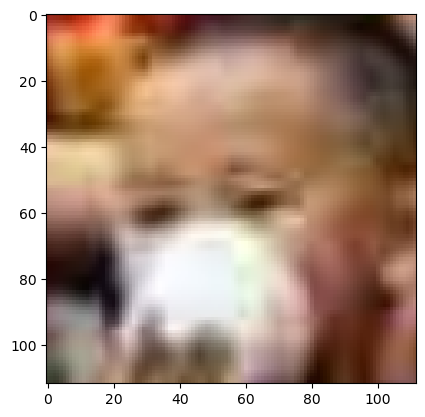

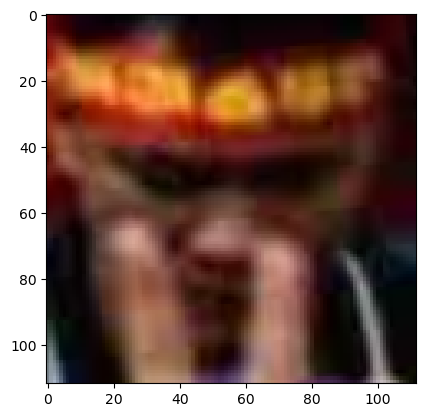

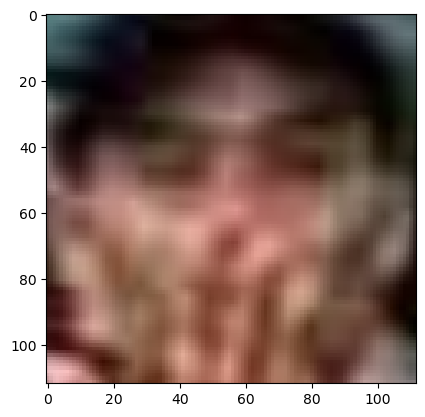

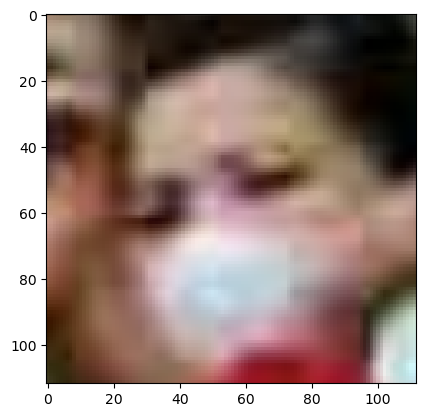

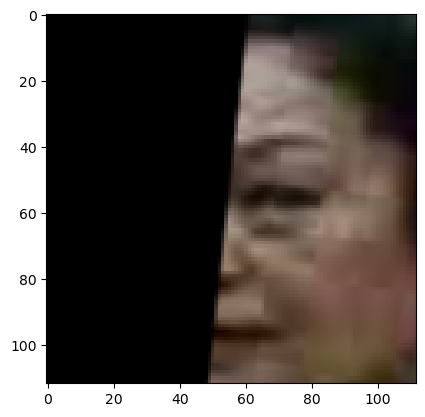

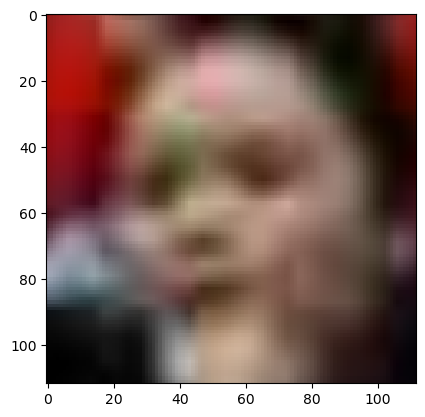

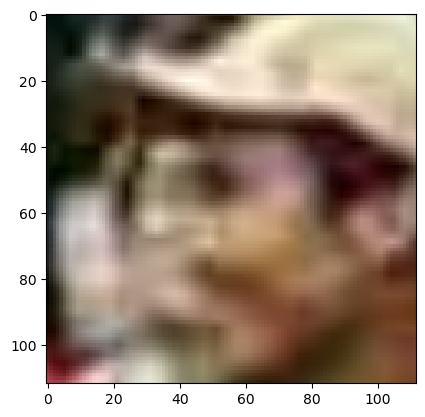

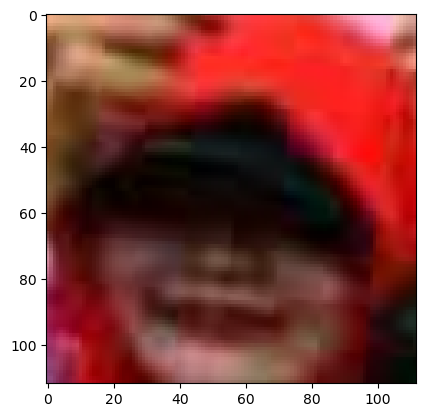

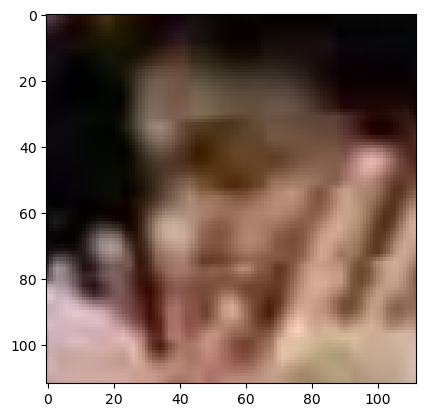

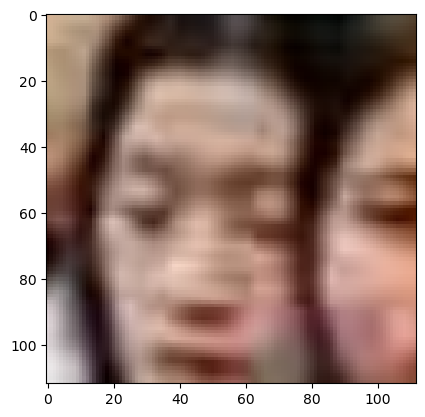

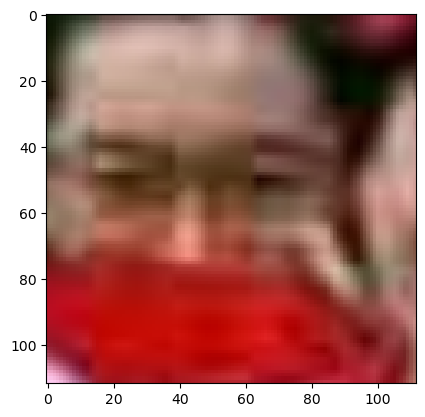

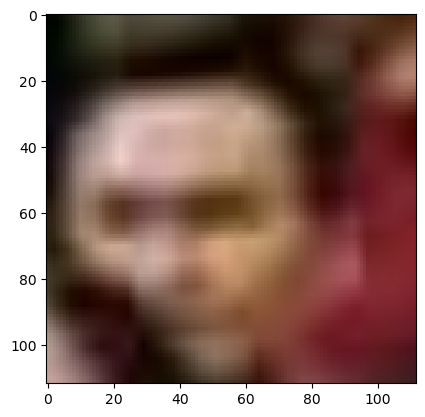

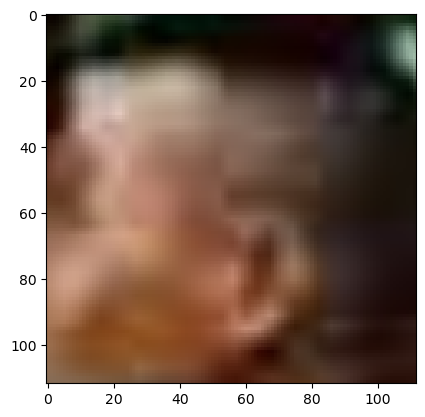

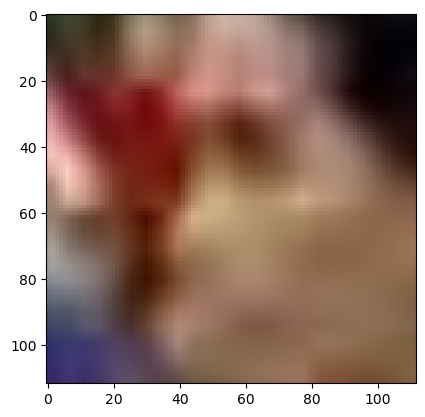

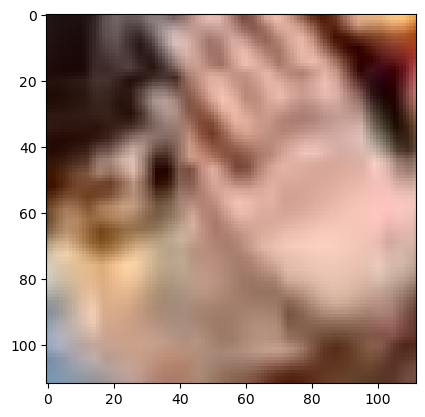

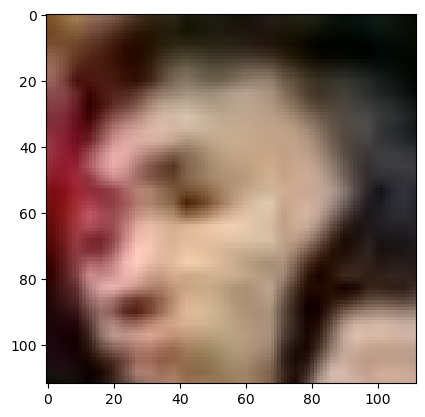

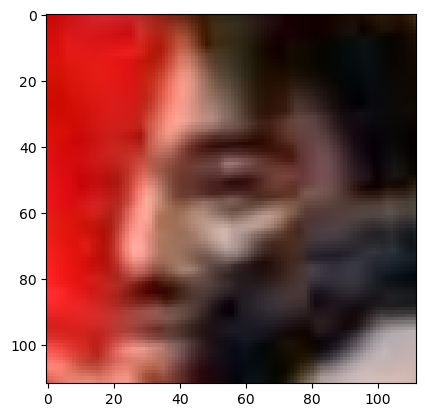

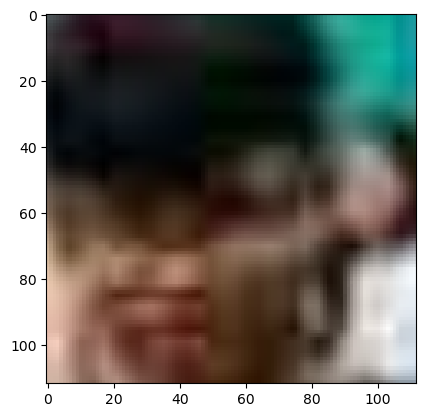

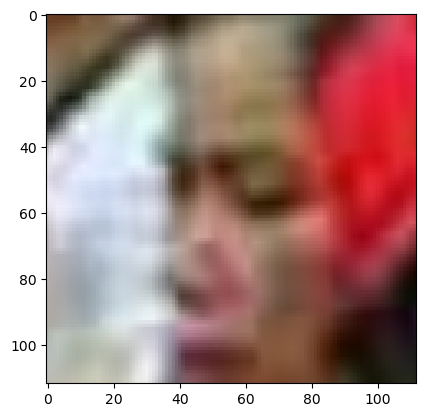

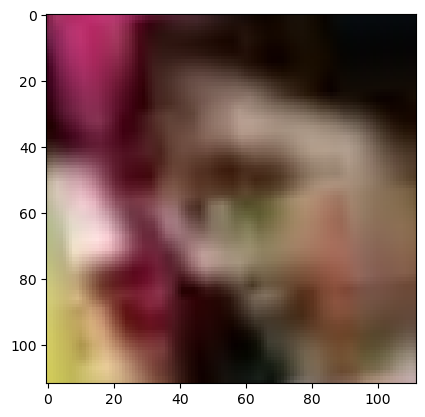

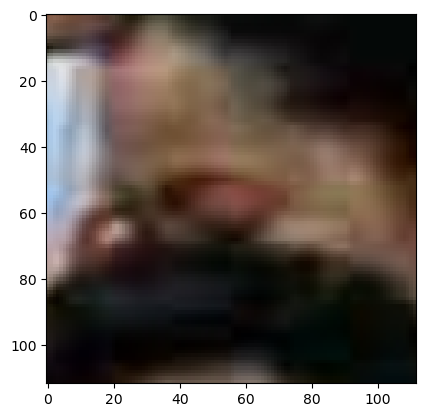

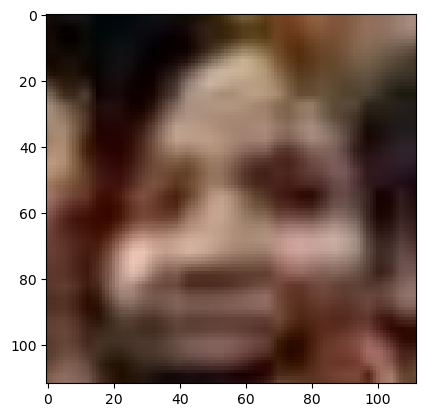

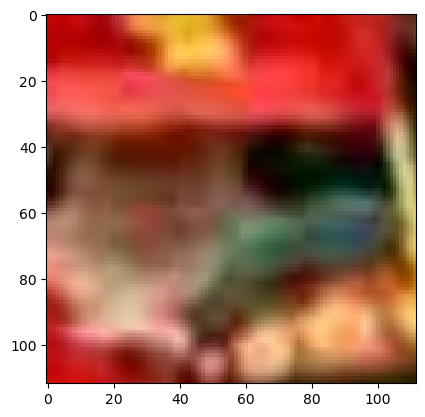

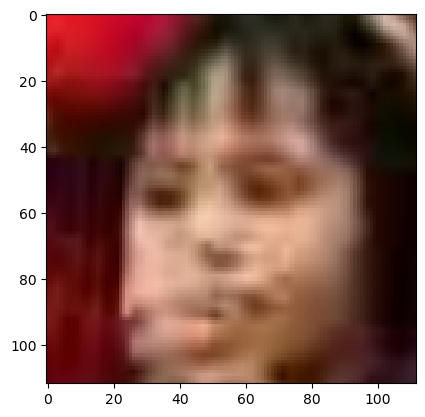

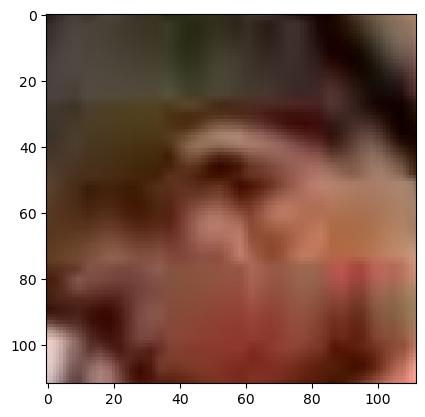

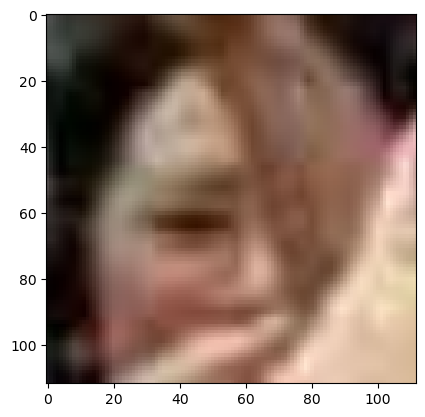

In [10]:

imgs = []
for i in landmarks:
    img = aligner.align(img1, i)
    imgs.append(img)
    plt.imshow(img, cmap="gray")
    plt.show()